# Лабораторна робота №3: Візуалізація даних
### Завдання 1. Обрати унікальний датасет з UCI
*Для роботи обрано **Automobile Data Set**.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
cols = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
        "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
        "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
        "fuel-system", "bore", "stroke", "compression-ratio", "horsepower",
        "peak-rpm", "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=cols, na_values="?")

print("Raw Data first 5 rows")
display(df.head())

Raw Data first 5 rows


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Завдання 2. Здійснити Data Cleaning
Перевірка наявності пропущених значень, видалення порожніх значень цільової змінної та заповнення інших пропусків.

In [2]:
print("Before Cleaning")
missing = df.isnull().sum()
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Attribute', 'Missing Count']
display(missing_df)

df_clean = df.copy()
df_clean = df_clean.dropna(subset=['price'])

num_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['num-of-doors'] = df_clean['num-of-doors'].fillna(df_clean['num-of-doors'].mode()[0])

print("\n Missing Values after cleaning")
missing_after = df_clean.isnull().sum().max()
print(f"Maximum missing values in any column: {missing_after}")

if missing_after == 0:
    print("Successful")

Before Cleaning


,Attribute,Missing Count
0,normalized-losses,41
1,num-of-doors,2
2,bore,4
3,stroke,4
4,horsepower,2
5,peak-rpm,2
6,price,4



 Missing Values after cleaning
Maximum missing values in any column: 0
Successful


### Завдання 3. Побудувати графіки залежності одного integer/real атрибута від іншого 
1. Лінійна регресія (Scatter plot + Trendline) залежності ціни від об'єму двигуна.
2. Поліноміальна регресія (Lineplot/Scatter) залежності витрати палива в місті від потужності (кінських сил).

Scatter Plot with Linear Trendline


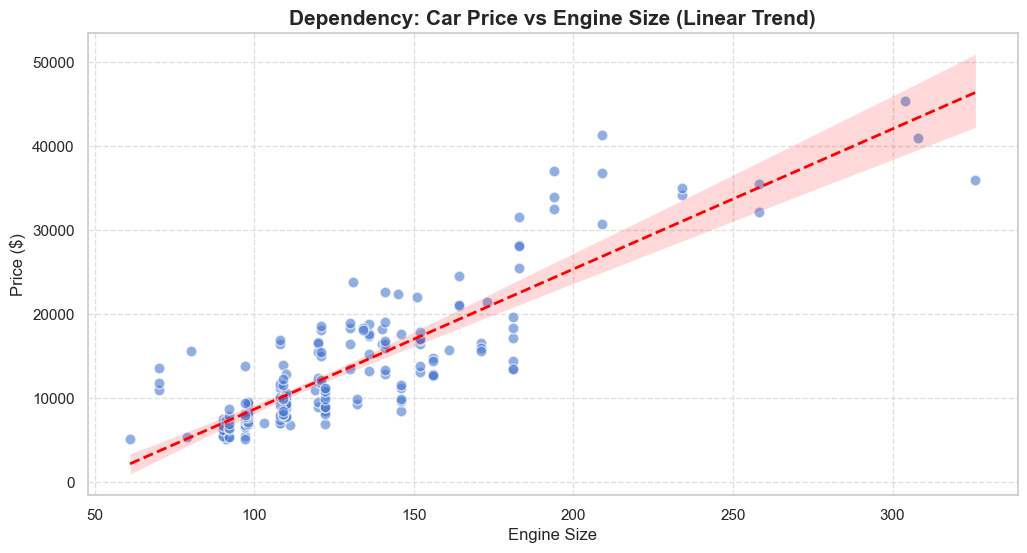


Scatter/Lineplot with Polynomial Trendline


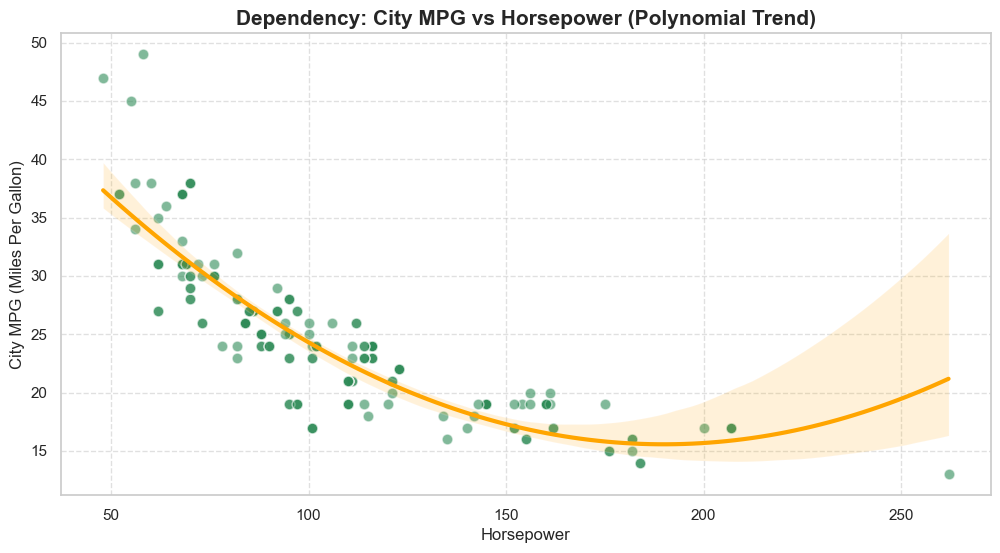

In [13]:
print("Scatter Plot with Linear Trendline")

plt.figure(figsize=(12, 6))
sns.regplot(
    data=df_clean, x='engine-size', y='price',
    scatter_kws={'s': 60, 'alpha': 0.6, 'edgecolor': 'white'},
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}
)
plt.title('Dependency: Car Price vs Engine Size (Linear Trend)', fontsize=15, fontweight='bold')
plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nScatter/Lineplot with Polynomial Trendline")

plt.figure(figsize=(12, 6))
sns.regplot(
    data=df_clean, x='horsepower', y='city-mpg', order=2,
    scatter_kws={'s': 60, 'alpha': 0.6, 'color': 'seagreen', 'edgecolor': 'white'},
    line_kws={'color': 'orange', 'linewidth': 3}
)
plt.title('Dependency: City MPG vs Horsepower (Polynomial Trend)', fontsize=15, fontweight='bold')
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('City MPG (Miles Per Gallon)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Завдання 4. Побудувати гістограму по одному з атрибутів (5 діапазонів)
Розподіл цін на автомобілі, розбитий суворо на 5 діапазонів (bins). Для кращої аналітики на графік накладено вертикальні лінії середнього значення та медіани.

Histogram with Mean/Median lines


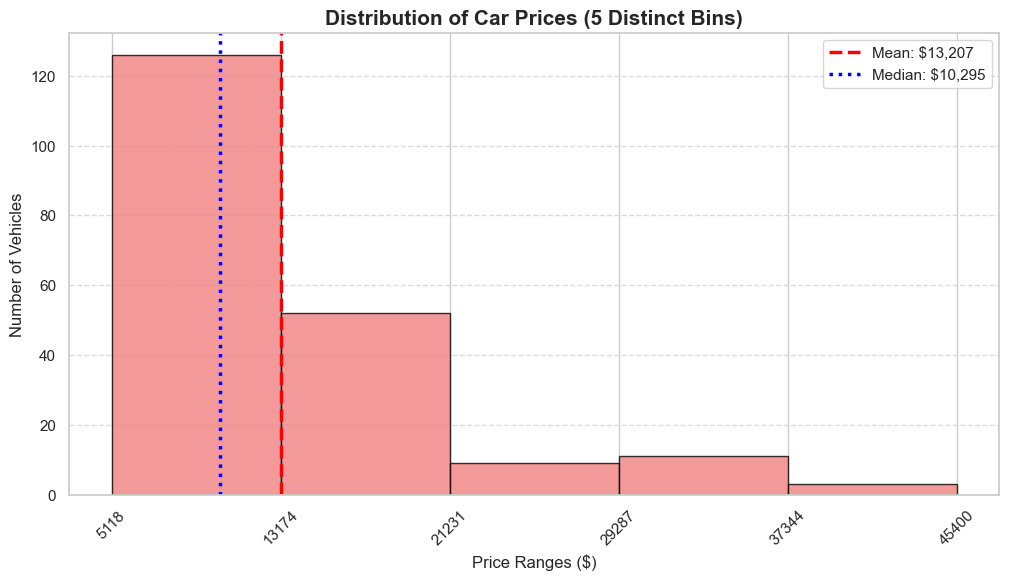


Bin Details Table:


,Bin Start ($),Bin End ($),Car Count
0,5118.0,13174.4,126
1,13174.4,21230.8,52
2,21230.8,29287.2,9
3,29287.2,37343.6,11
4,37343.6,45400.0,3


In [12]:
print("Histogram with Mean/Median lines")

plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df_clean['price'], bins=5, color='lightcoral', edgecolor='black', alpha=0.8)

mean_price = df_clean['price'].mean()
median_price = df_clean['price'].median()

plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2.5, label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='blue', linestyle='dotted', linewidth=2.5, label=f'Median: ${median_price:,.0f}')

plt.title('Distribution of Car Prices (5 Distinct Bins)', fontsize=15, fontweight='bold')
plt.xlabel('Price Ranges ($)', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(bins, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

bin_df = pd.DataFrame({'Bin Start ($)': np.round(bins[:-1], 2), 'Bin End ($)': np.round(bins[1:], 2), 'Car Count': counts.astype(int)})
print("\nBin Details Table:")
display(bin_df)

### Завдання 5. Графіки за прикладами статті з Medium (Багатовимірні дані)
1. **Correlation Heatmap**  для пошуку взаємозв'язків між усіма числовими атрибутами.
2. **Boxplot + Stripplot** для аналізу розподілу цін за категорією кузова з відображенням кожної окремої точки даних.
3. **Multidimensional Pairplot** для попарного порівняння ключових характеристик з урахуванням типу палива.

Correlation Matrix


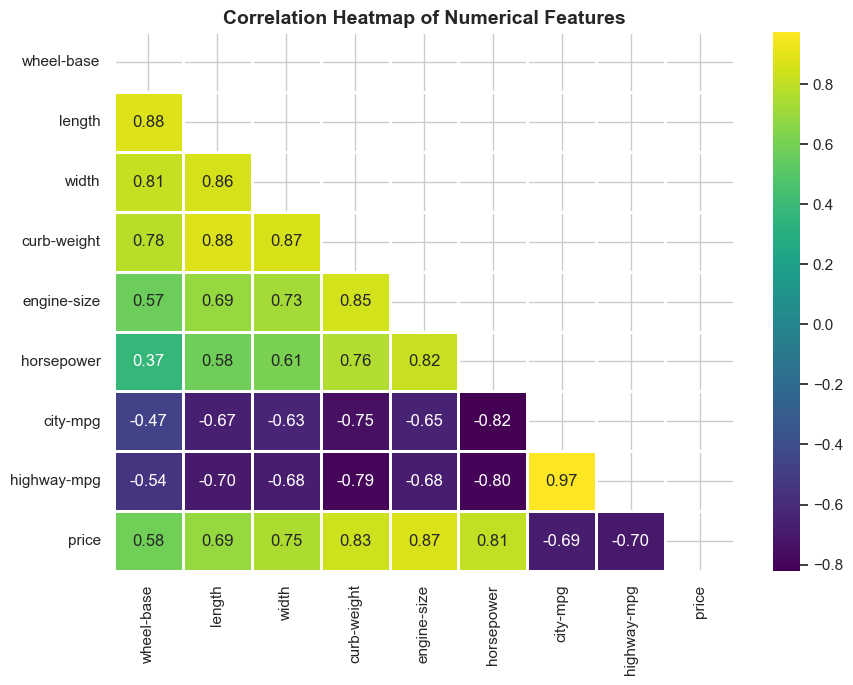


Boxplot with Overlaid Stripplot


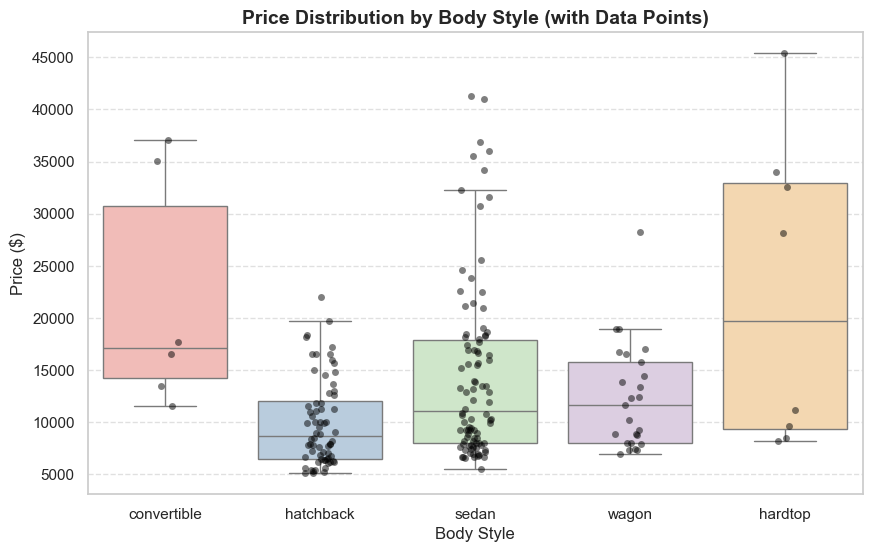


Multidimensional Pairplot


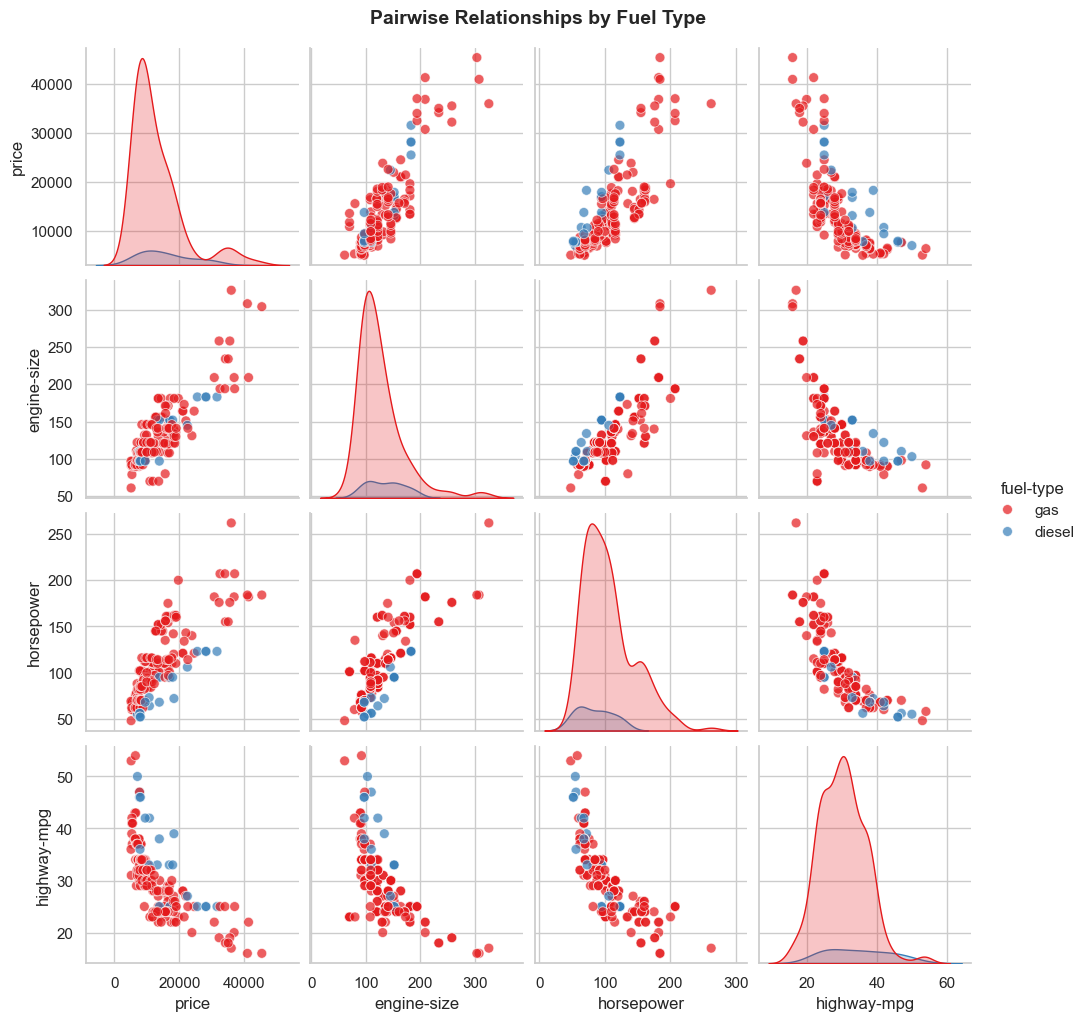

In [21]:
print("Correlation Matrix")

plt.figure(figsize=(10, 7))
num_features = ['wheel-base', 'length', 'width', 'curb-weight', 'engine-size', 'horsepower', 'city-mpg', 'highway-mpg', 'price']
corr_matrix = df_clean[num_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='viridis', linewidths=1, linecolor='white')

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

print("\nBoxplot with Overlaid Stripplot")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='body-style', y='price', hue='body-style', palette='Pastel1', fliersize=0, legend=False)
sns.stripplot(data=df_clean, x='body-style', y='price', color='black', alpha=0.5, size=5, jitter=True)

plt.title('Price Distribution by Body Style (with Data Points)', fontsize=14, fontweight='bold')
plt.xlabel('Body Style', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


print("\nMultidimensional Pairplot")
pair_features = ['price', 'engine-size', 'horsepower', 'highway-mpg', 'fuel-type']
pair_plot = sns.pairplot(df_clean[pair_features], hue='fuel-type', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.7, 's': 50})
pair_plot.fig.suptitle('Pairwise Relationships by Fuel Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Завдання 6. Інші графіки, що покажуть корисну інформацію про датасет
1. **Barplot з анотаціями**: Демонструє середню вартість автомобілів у розрізі брендів.
2. **Violinplot + Stripplot**: Детально показує форму розподілу цін залежно від типу приводу автомобіля.

Barplot with Value Annotations


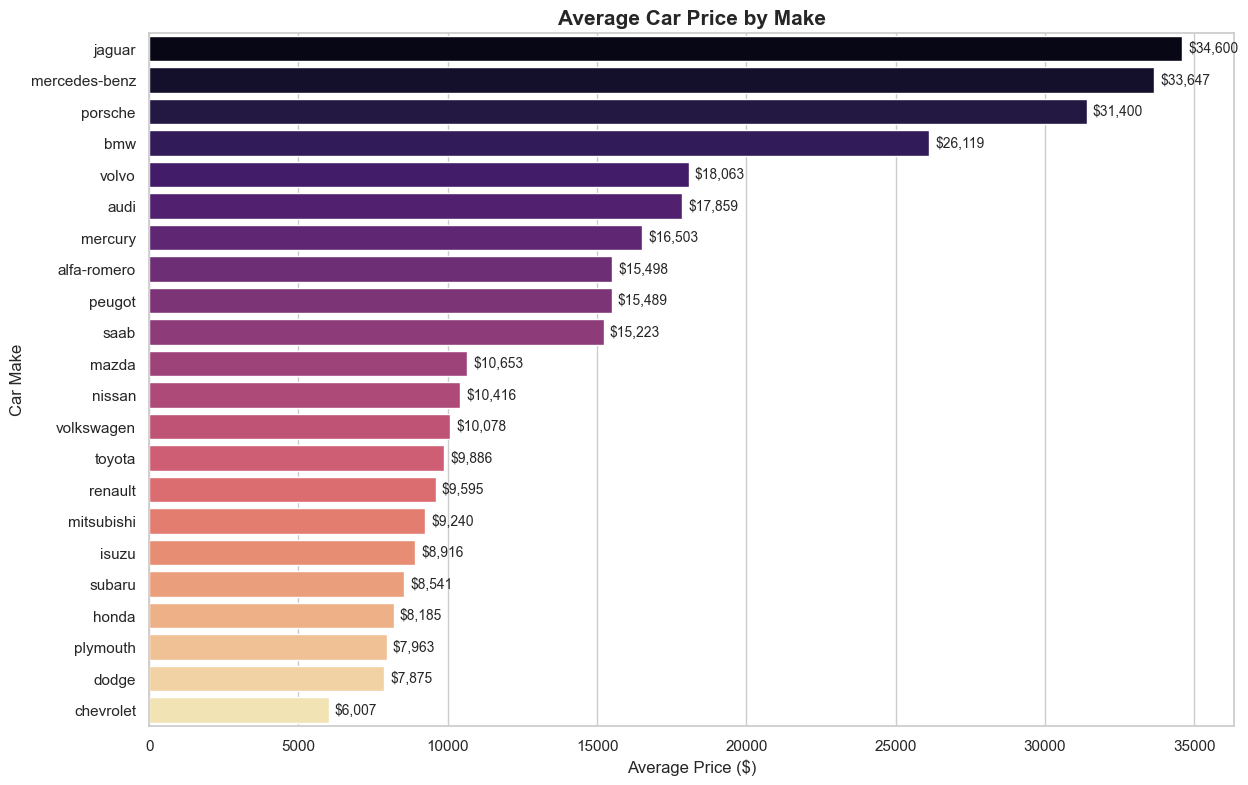


Violinplot with Overlaid Stripplot


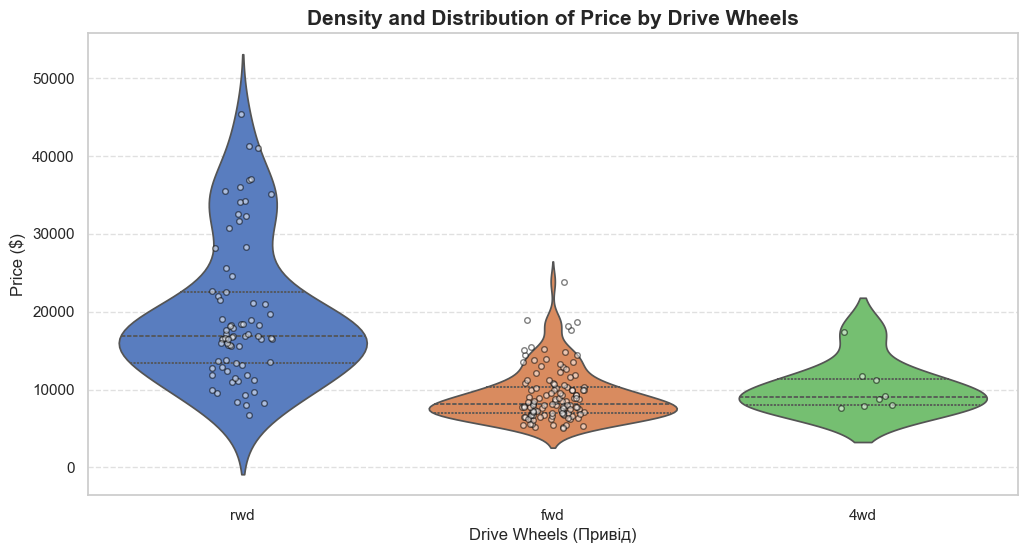

In [16]:
print("Barplot with Value Annotations")

plt.figure(figsize=(14, 9))
avg_price = df_clean.groupby('make')['price'].mean().sort_values(ascending=False).reset_index()
ax = sns.barplot(data=avg_price, x='price', y='make', hue='make', palette='magma', legend=False)

plt.title('Average Car Price by Make', fontsize=15, fontweight='bold')
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Car Make', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 200, p.get_y() + p.get_height() / 2, f'${width:,.0f}', ha='left', va='center', fontsize=10)
plt.show()

print("\nViolinplot with Overlaid Stripplot")

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x='drive-wheels', y='price', hue='drive-wheels', palette='muted', inner='quartile', legend=False)
sns.stripplot(data=df_clean, x='drive-wheels', y='price', color='white', edgecolor='black', linewidth=1, alpha=0.5, size=4, jitter=True)

plt.title('Density and Distribution of Price by Drive Wheels', fontsize=15, fontweight='bold')
plt.xlabel('Drive Wheels (Привід)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()